# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 34     |  |
| :-------------|:-------------|
| Pieter Otten| 6332463 |
| Casper Aaldering | 6243193 |
| Rune Veraart | 6439748 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Pieter', 'Casper', 'Rune']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Testen voltooid | 12:00 |
| Algoritme af | 16:00 |
| groep aanwezig 1 | 10:25-12:45 |
| groep aanwezig 2 | 13:30 - 17:00 |
| Pauze 1 | 12:45 - 13:30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF
import pandas as pd

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [34]

<img src="Senstest.jpeg" width="400">

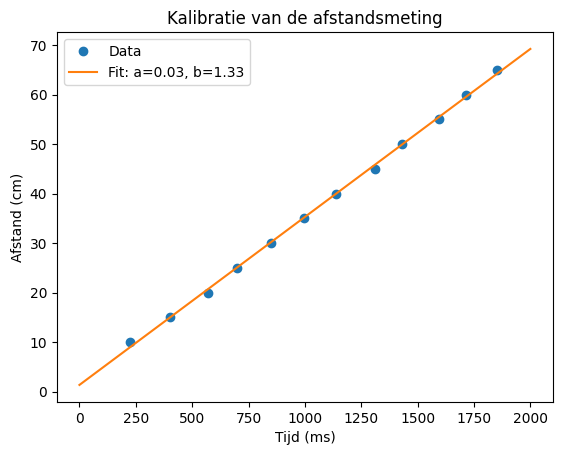

De snelheid van het geluid is ongeveer 0.03 cm/ms
De intercept is ongeveer 1.33 cm


In [3]:
from scipy.optimize import curve_fit
# verwerk hier jullie kalibratiemetingen
tijd = np.array([225, 400, 570, 700, 850, 995, 1137, 1310, 1430, 1595, 1713, 1852])
afstand = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65])

def geluid(t,a,b):
    return a*t+b

popt, cov = curve_fit(geluid, tijd,afstand) 

x1 = np.linspace(0, 2000, 100)
y1 = geluid(x1, *popt)

plt.figure()
plt.plot(tijd, afstand, 'o', label='Data')
plt.plot(x1, y1, '-', label='Fit: a=%.2f, b=%.2f' % tuple(popt))
plt.xlabel('Tijd (ms)')
plt.ylabel('Afstand (cm)')
plt.title('Kalibratie van de afstandsmeting')
plt.legend()
plt.show()

print(f"De snelheid van het geluid is ongeveer {popt[0]:.2f} cm/ms")
print(f"De intercept is ongeveer {popt[1]:.2f} cm")


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.6
1   0  30   0  20  41.4
2  40   0  30   0  40.4
3  30   0  20   0  40.8


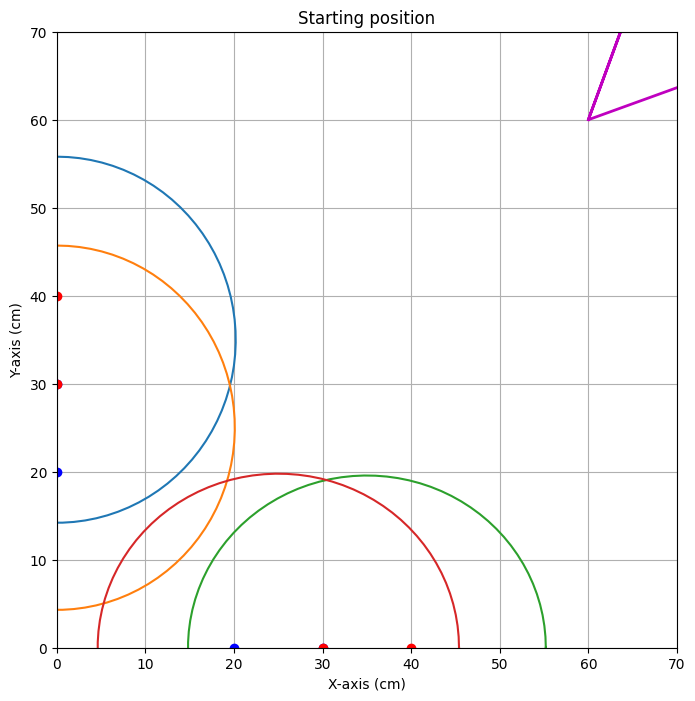


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.905


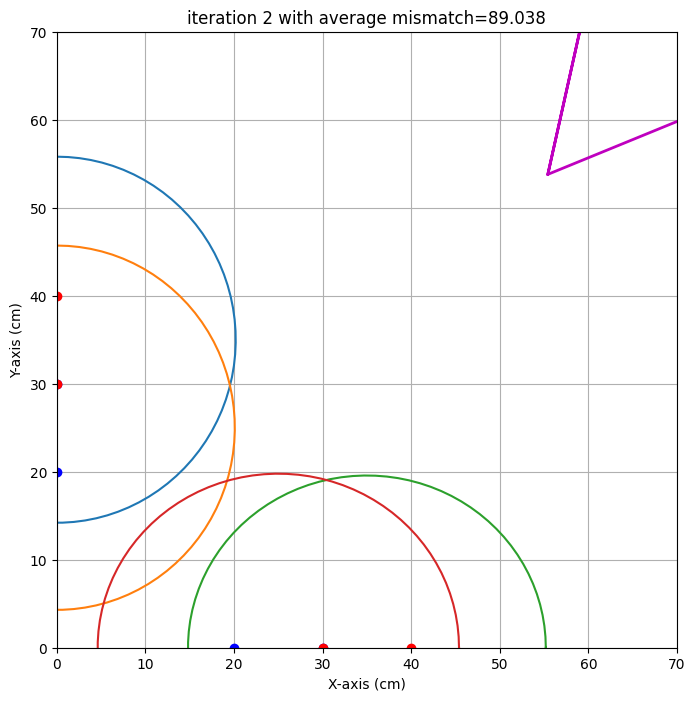

end iteration 2 with average mismatch=89.038


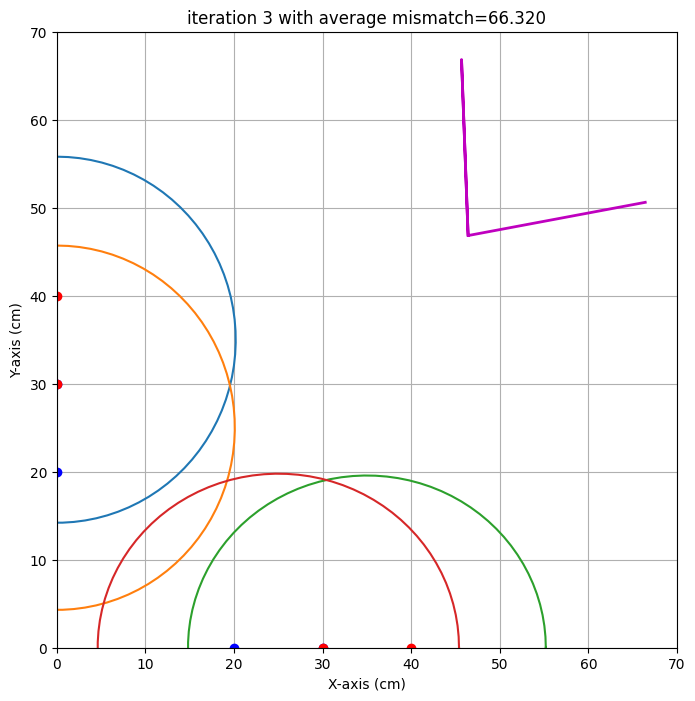

end iteration 3 with average mismatch=66.320


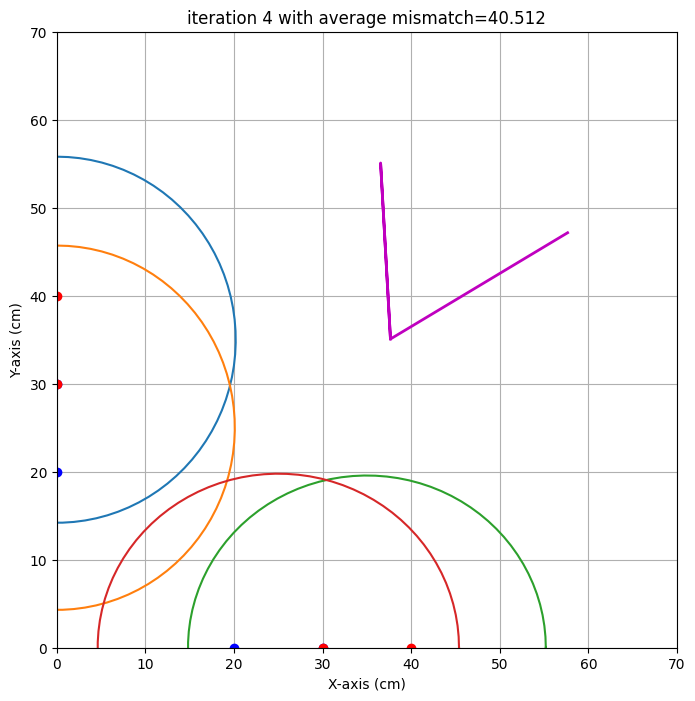

end iteration 4 with average mismatch=40.512


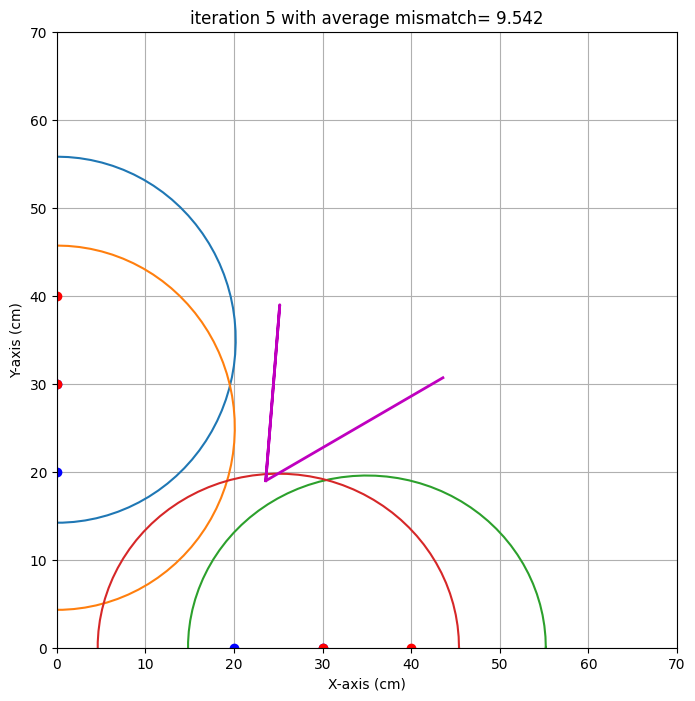

end iteration 5 with average mismatch= 9.542


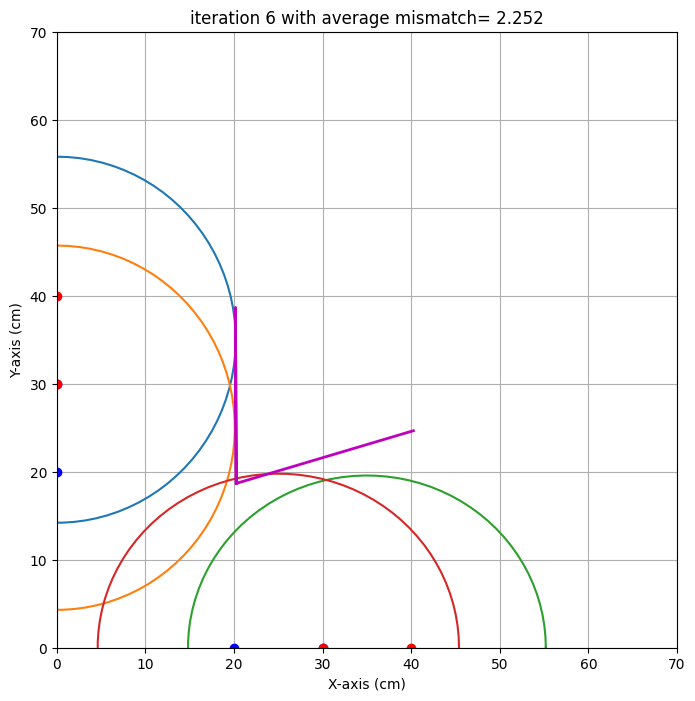

end iteration 6 with average mismatch= 2.252


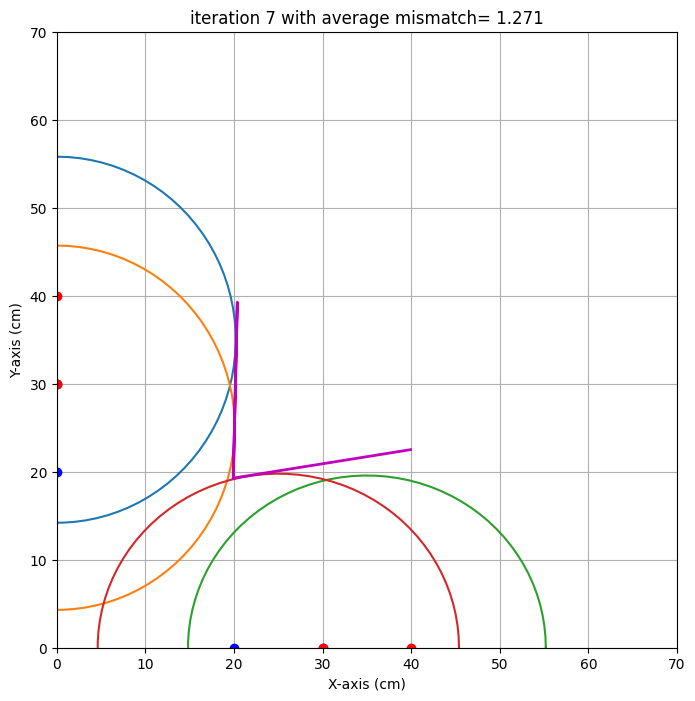

end iteration 7 with average mismatch= 1.271


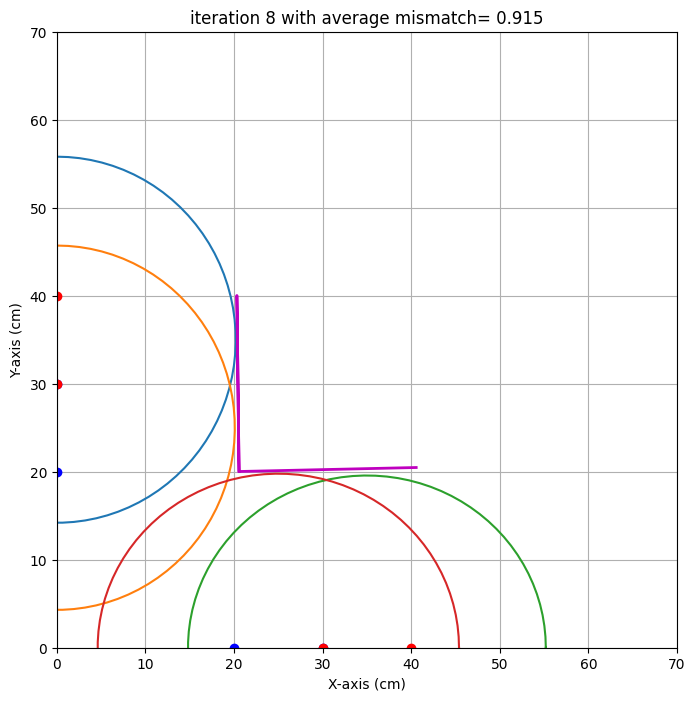

end iteration 8 with average mismatch= 0.915


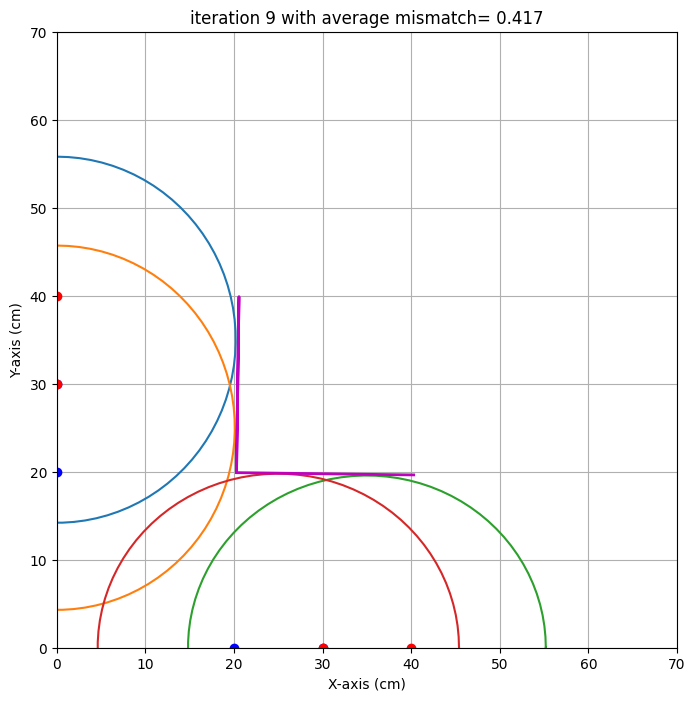

end iteration 9 with average mismatch= 0.417
end iteration 10 with average mismatch= 0.408


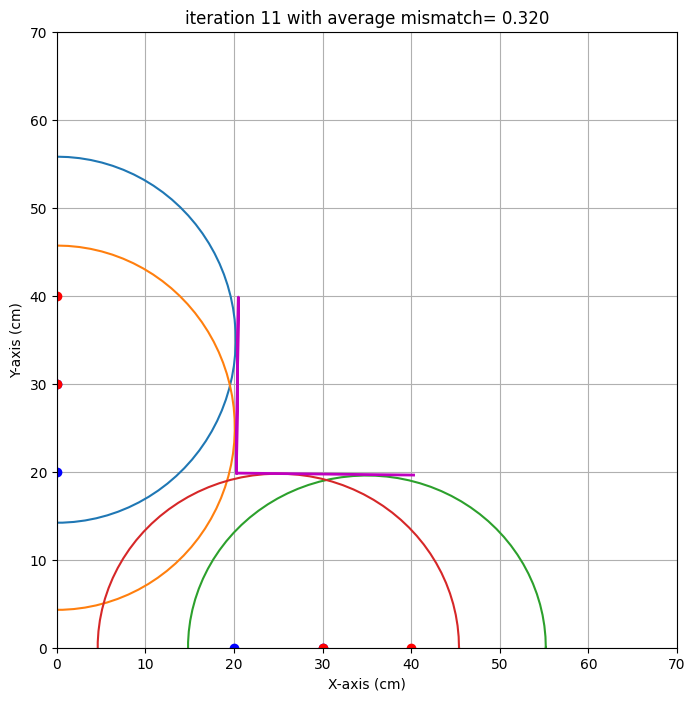

end iteration 11 with average mismatch= 0.320


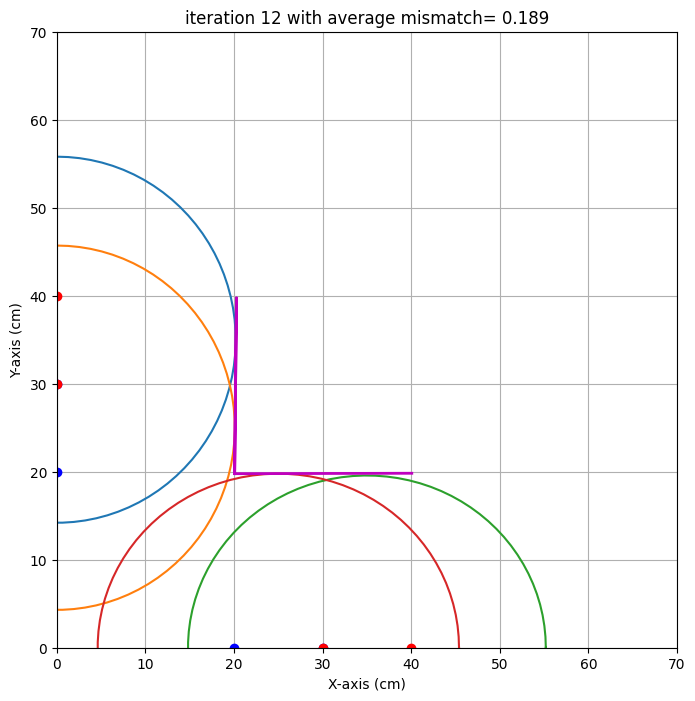

end iteration 12 with average mismatch= 0.189


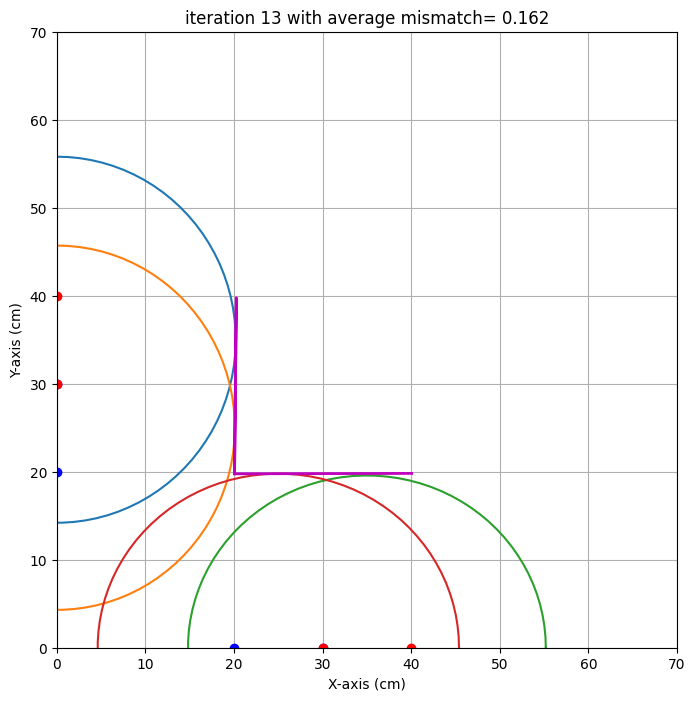

end iteration 13 with average mismatch= 0.162
end iteration 14 with average mismatch= 0.158
end iteration 15 with average mismatch= 0.155
end iteration 16 with average mismatch= 0.154
end iteration 17 with average mismatch= 0.153
end iteration 18 with average mismatch= 0.153
end iteration 19 with average mismatch= 0.153
end iteration 20 with average mismatch= 0.153
end iteration 21 with average mismatch= 0.153
end iteration 22 with average mismatch= 0.153
end iteration 23 with average mismatch= 0.153
end iteration 24 with average mismatch= 0.153
end iteration 25 with average mismatch= 0.153
end iteration 26 with average mismatch= 0.153
end iteration 27 with average mismatch= 0.153
end iteration 28 with average mismatch= 0.153
end iteration 29 with average mismatch= 0.153
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.153
#############

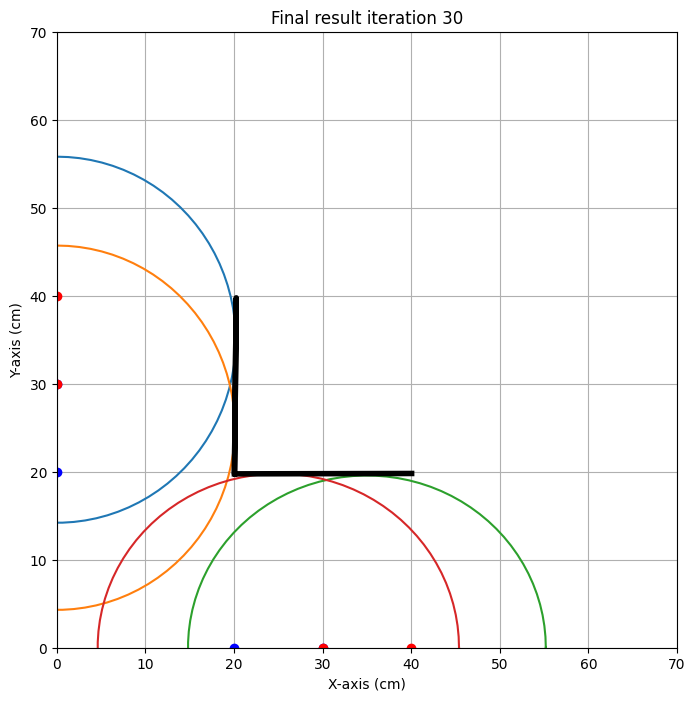

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.6],
    [0,30,0,20,41.4],
    #[0,10,0,20,3.0],
    [40,0,30,0,40.4],
    [30,0,20,0,40.8],
    #[10,0,20,0,6.0],
   # [10,0,0,10,7.0]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.0 cm met een standaardafwijking van 0.0 cm 
y0: 19.8 cm met een standaardafwijking van 0.0 cm 
alpha: 0.1 graden met een standaardafwijking van 0.0 graad 
beta: 0.6 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Pieter]

<img src="AlgPieter.jpeg" width="400">

#### algoritme [Casper]

<img src="AlgJasper.jpeg" width="400">

#### algoritme [Rune]

<img src="AlgRune.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':46.0,
           'y0':44.0,
           'alpha' :6,
           'beta' :-10,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Pieter' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[35,0,50,0,94],
    [50,0,65,0,89],
    [45,0,60,0,90.7],
    [47,0,62,0,89.41],
    [49,0,64,0,88.9],
    [51,0,66,0,89.65],  
    [53,0,68,0,90.4],#x = 0
    [0,40,0,55,87.5],
    [0,43,0,58,88.2],
    [0,46,0,61,92],
    [0,49,0,64,93.0],
    ]),
       'Rune' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,40,0,96.5],
    #[40,0,50,0,],
    [50,0,60,0,87.6],
    [60,0,70,0,90.6],
    [40,0,60,0,92.8],
    [50,0,70,0,90.6],
    [0,30,0,40,101],  
    [0,40,0,50,87.4],
    [0,30,0,50,90.2]
    ]),
       'Casper' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45,0,70,0,90],
    #[30,0,60,0,41.6],
    [45,0,55,0,89.9],
    [55,0,70,0,89.4],
    [0,45,0,55,89.5],
    [0,45,0,65,92],
    ])
      }

## Opdracht 7: Evaluatie.

Pieter
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  50   0  65   0  89.00
1  45   0  60   0  90.70
2  47   0  62   0  89.41
3  49   0  64   0  88.90
4  51   0  66   0  89.65
5  53   0  68   0  90.40
6   0  40   0  55  87.50
7   0  43   0  58  88.20
8   0  46   0  61  92.00
9   0  49   0  64  93.00


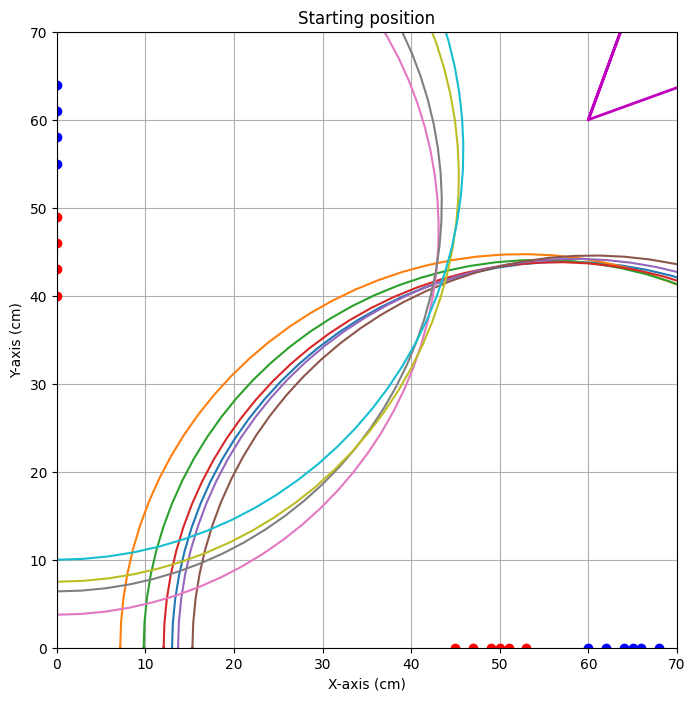


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=38.204


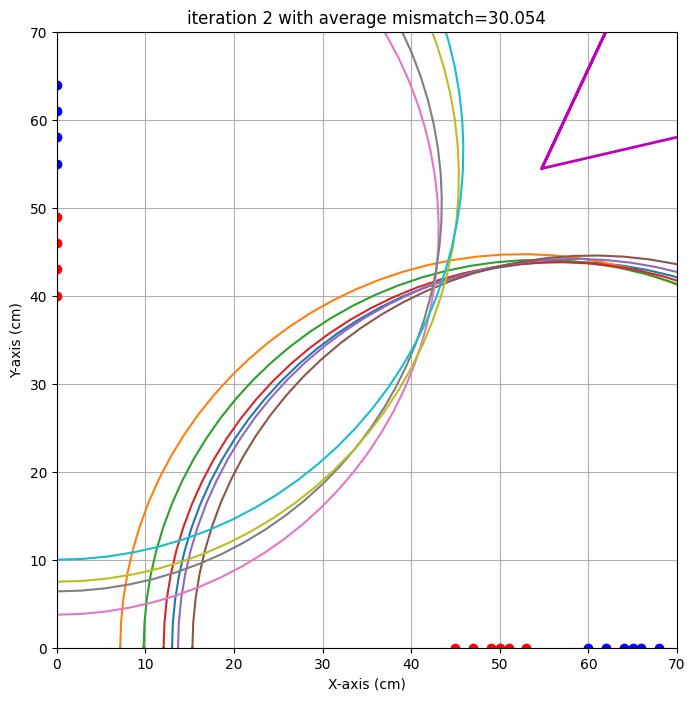

end iteration 2 with average mismatch=30.054


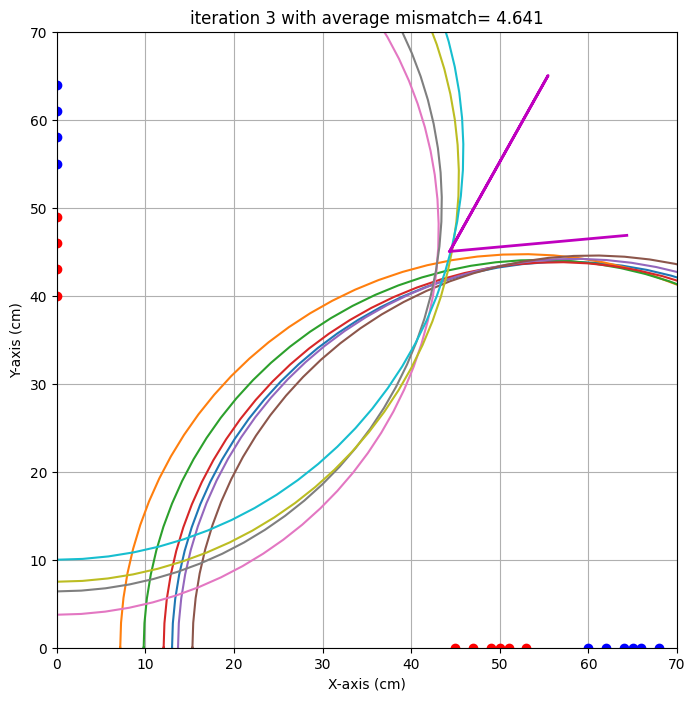

end iteration 3 with average mismatch= 4.641


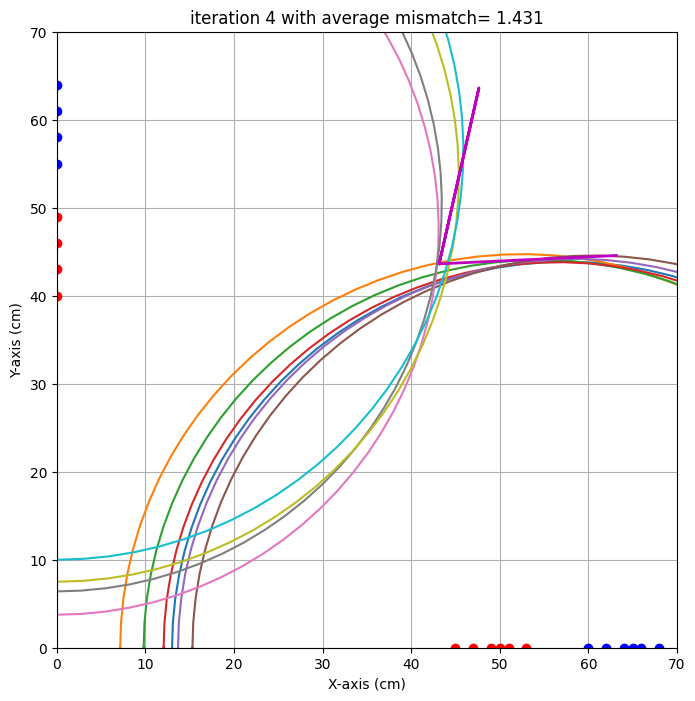

end iteration 4 with average mismatch= 1.431
end iteration 5 with average mismatch= 1.402


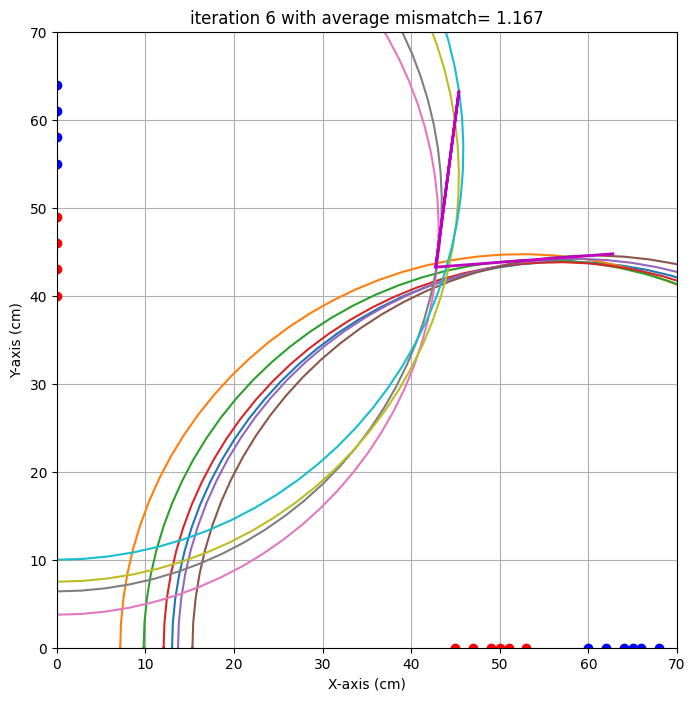

end iteration 6 with average mismatch= 1.167
end iteration 7 with average mismatch= 1.062
end iteration 8 with average mismatch= 1.062
end iteration 9 with average mismatch= 1.062
end iteration 10 with average mismatch= 1.012
end iteration 11 with average mismatch= 1.012
end iteration 12 with average mismatch= 1.012
end iteration 13 with average mismatch= 1.012
end iteration 14 with average mismatch= 1.012
end iteration 15 with average mismatch= 0.995
end iteration 16 with average mismatch= 0.992
end iteration 17 with average mismatch= 0.992
end iteration 18 with average mismatch= 0.992
end iteration 19 with average mismatch= 0.992
end iteration 20 with average mismatch= 0.992
end iteration 21 with average mismatch= 0.992
end iteration 22 with average mismatch= 0.992
end iteration 23 with average mismatch= 0.992
end iteration 24 with average mismatch= 0.992
end iteration 25 with average mismatch= 0.992
end iteration 26 with average mismatch= 0.992
end iteration 27 with average mismatch

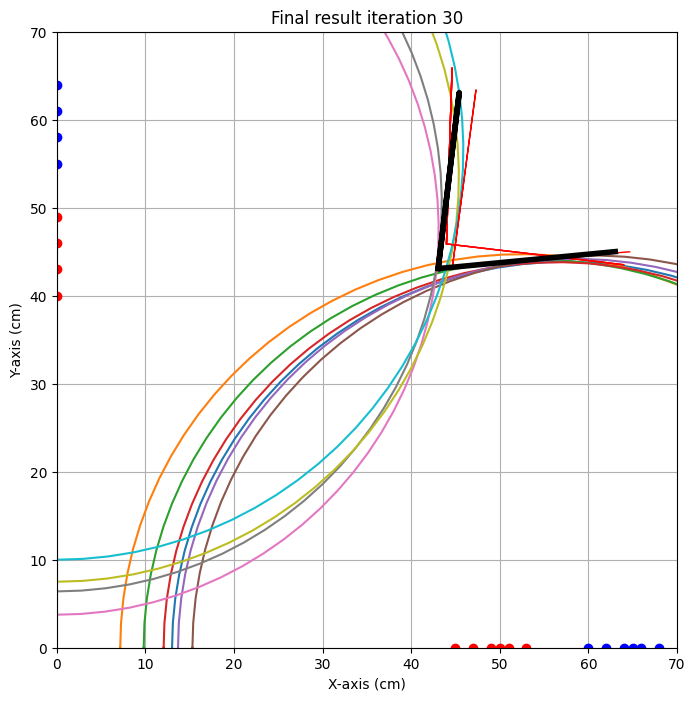

{'alpha': np.float64(5.50790127324956), 'alpha_eps': np.float64(12.248585733744353), 'beta': np.float64(6.784482673104627), 'beta_eps': np.float64(4.964403318849767), 'x0': np.float64(43.04520251268221), 'x0_eps': np.float64(1.6214050046512156), 'y0': np.float64(43.08365787816236), 'y0_eps': np.float64(2.802125611912132)}
Casper
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  70   0  90.0
1  45   0  55   0  89.9
2  55   0  70   0  89.4
3   0  45   0  55  89.5
4   0  45   0  65  92.0


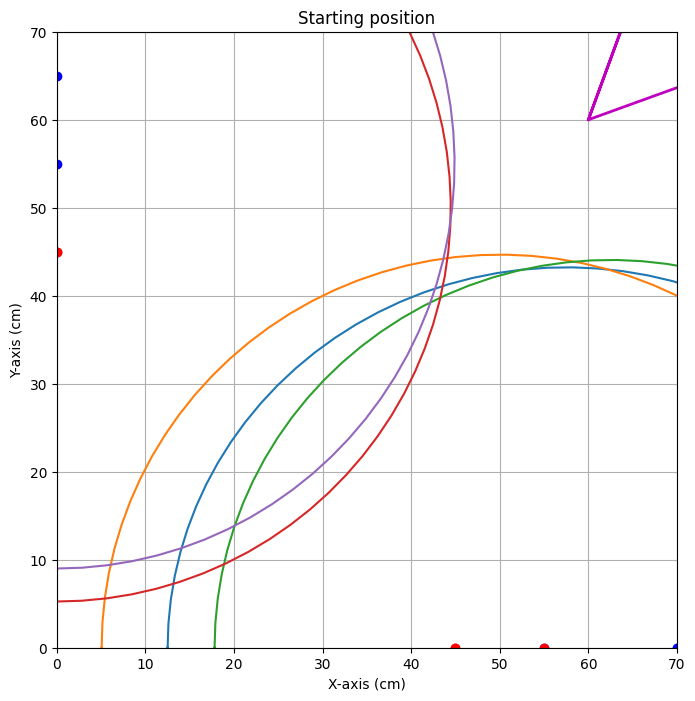


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=38.245


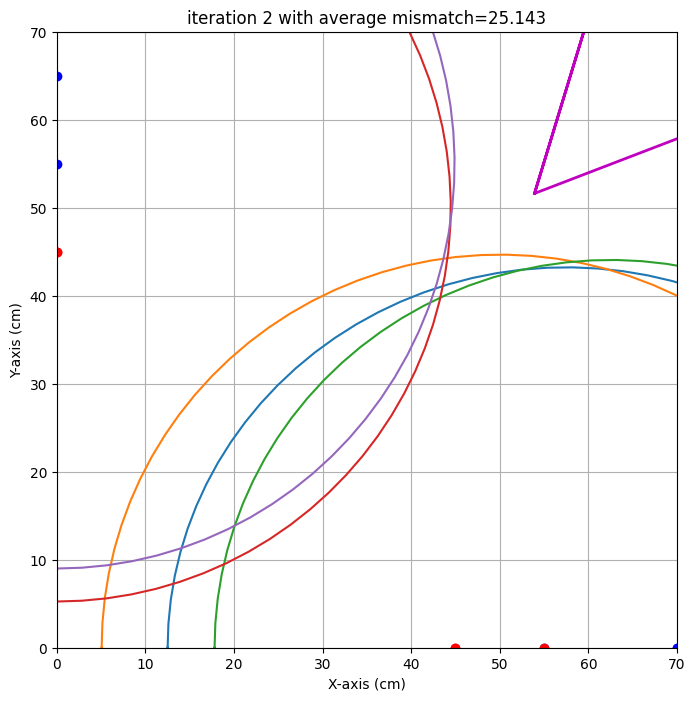

end iteration 2 with average mismatch=25.143


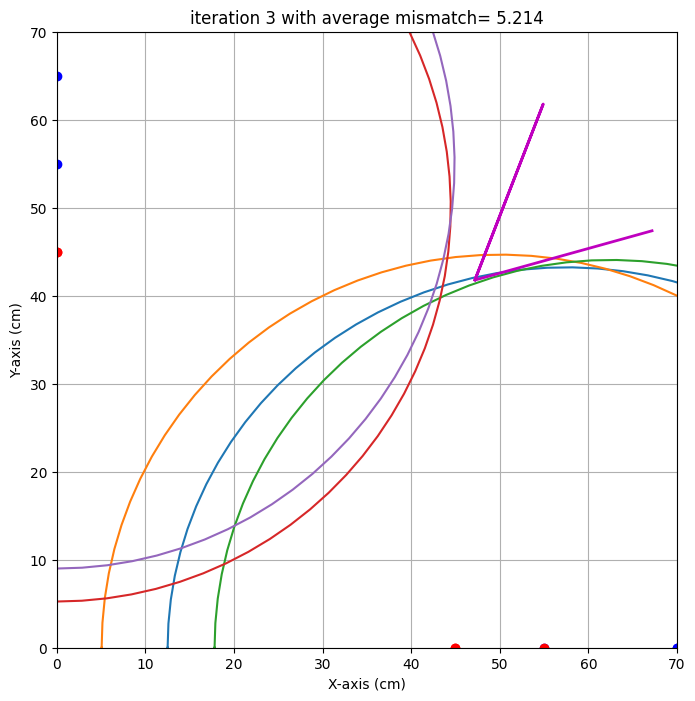

end iteration 3 with average mismatch= 5.214


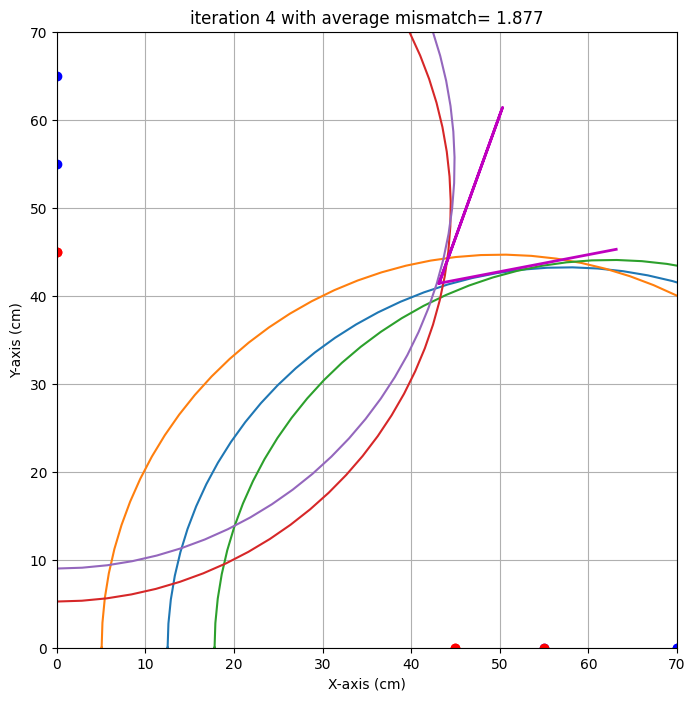

end iteration 4 with average mismatch= 1.877


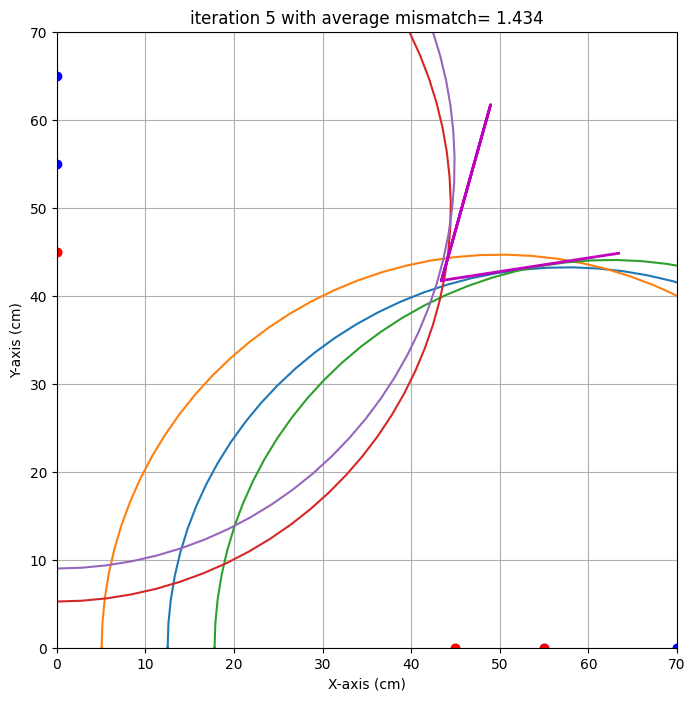

end iteration 5 with average mismatch= 1.434
end iteration 6 with average mismatch= 1.425


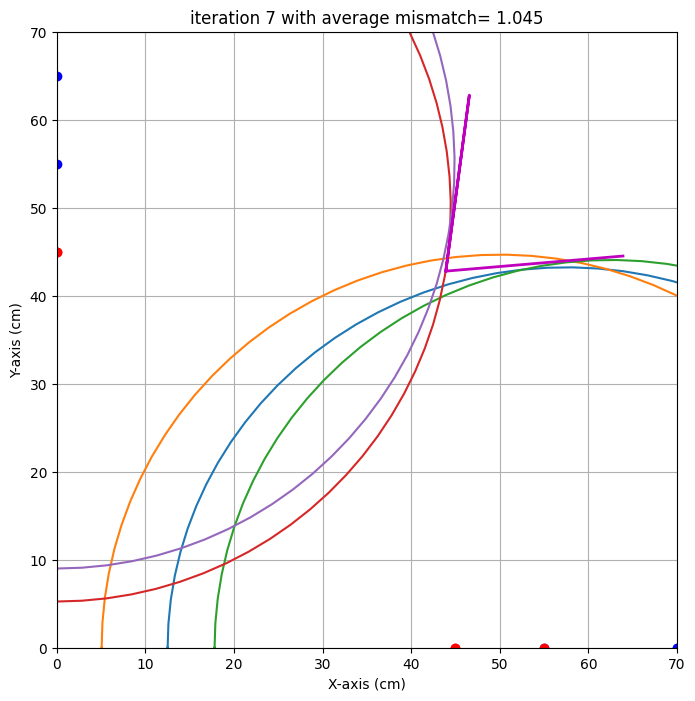

end iteration 7 with average mismatch= 1.045
end iteration 8 with average mismatch= 1.006
end iteration 9 with average mismatch= 0.997
end iteration 10 with average mismatch= 0.995
end iteration 11 with average mismatch= 0.995
end iteration 12 with average mismatch= 0.995
end iteration 13 with average mismatch= 0.995
end iteration 14 with average mismatch= 0.988
end iteration 15 with average mismatch= 0.939
end iteration 16 with average mismatch= 0.931
end iteration 17 with average mismatch= 0.927
end iteration 18 with average mismatch= 0.925
end iteration 19 with average mismatch= 0.925
end iteration 20 with average mismatch= 0.925
end iteration 21 with average mismatch= 0.925
end iteration 22 with average mismatch= 0.925
end iteration 23 with average mismatch= 0.925
end iteration 24 with average mismatch= 0.916
end iteration 25 with average mismatch= 0.913
end iteration 26 with average mismatch= 0.913
end iteration 27 with average mismatch= 0.913
end iteration 28 with average mismatc

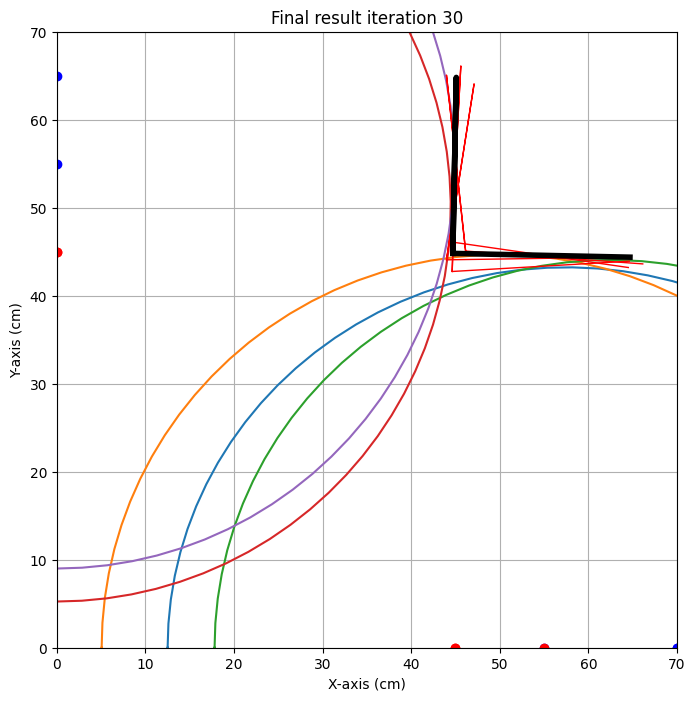

{'alpha': np.float64(-1.228971416626658), 'alpha_eps': np.float64(7.043288675290144), 'beta': np.float64(1.111145741134521), 'beta_eps': np.float64(7.755391798202988), 'x0': np.float64(44.70091413395245), 'x0_eps': np.float64(1.443308897142046), 'y0': np.float64(44.808998185046335), 'y0_eps': np.float64(2.0543800141402713)}
Rune
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  50   0  60   0   87.6
1  60   0  70   0   90.6
2  40   0  60   0   92.8
3  50   0  70   0   90.6
4   0  30   0  40  101.0
5   0  40   0  50   87.4
6   0  30   0  50   90.2


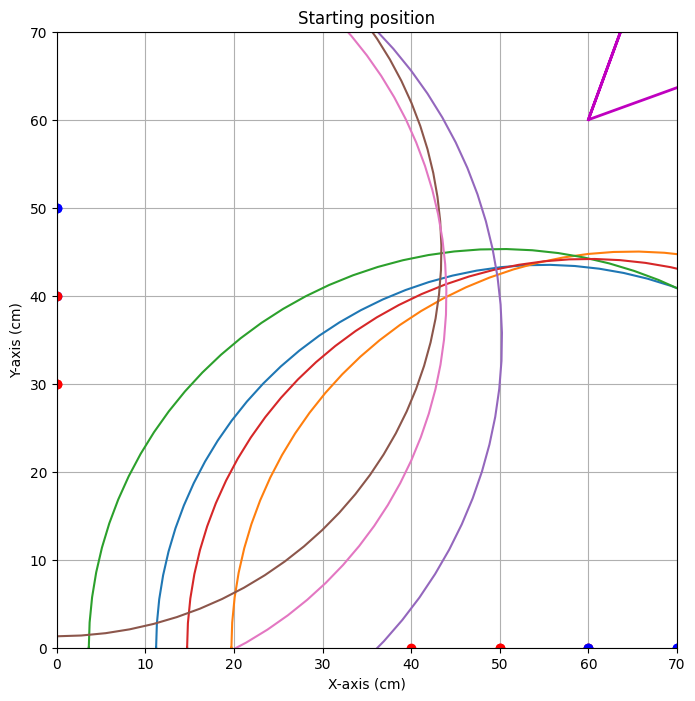


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=39.601


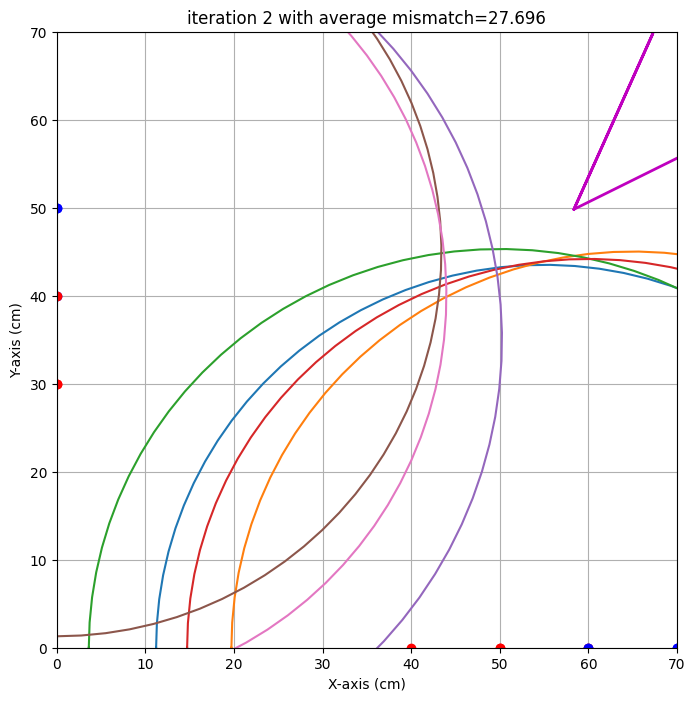

end iteration 2 with average mismatch=27.696


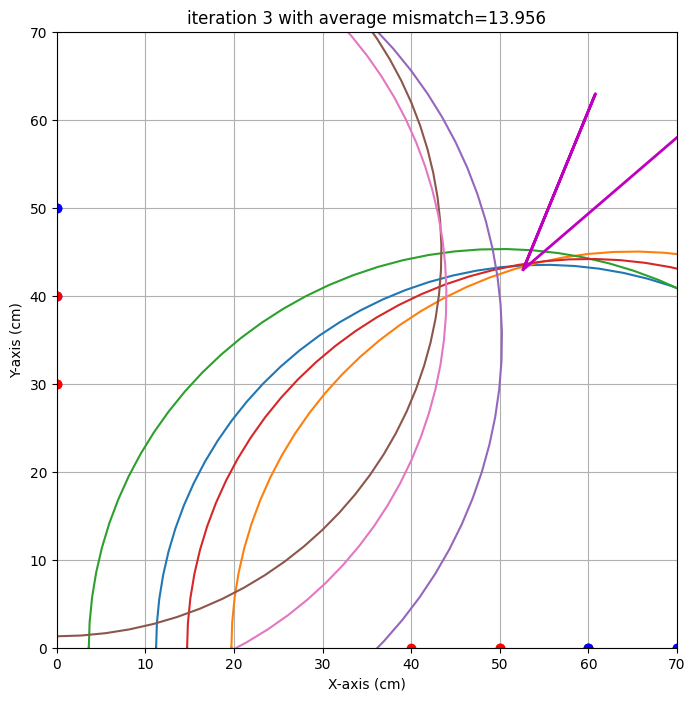

end iteration 3 with average mismatch=13.956


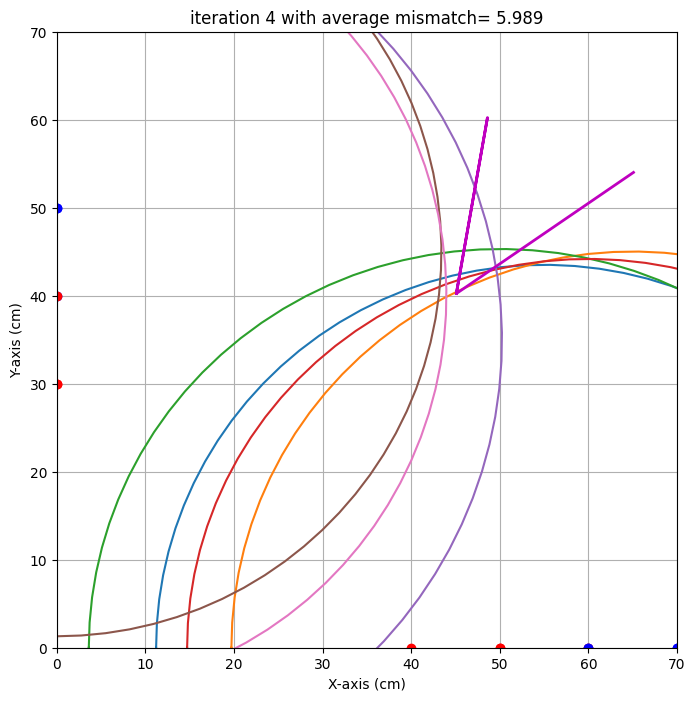

end iteration 4 with average mismatch= 5.989


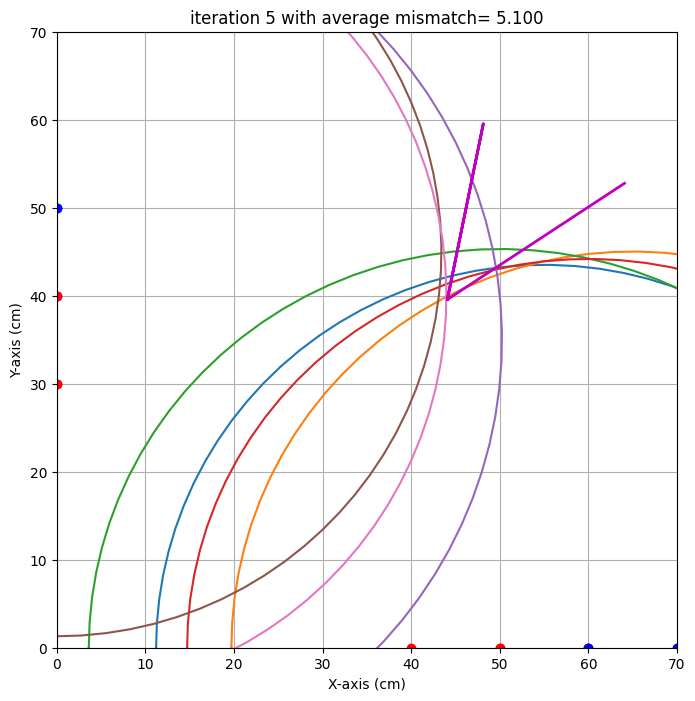

end iteration 5 with average mismatch= 5.100


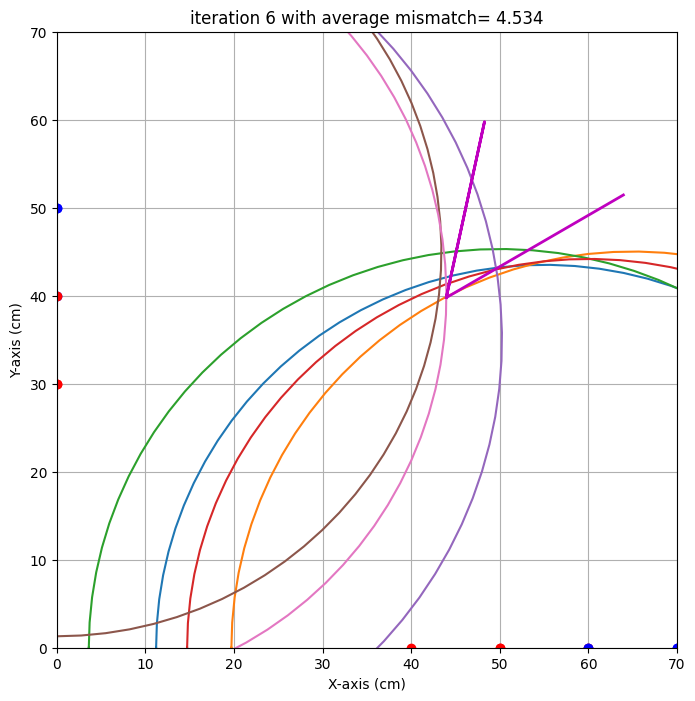

end iteration 6 with average mismatch= 4.534


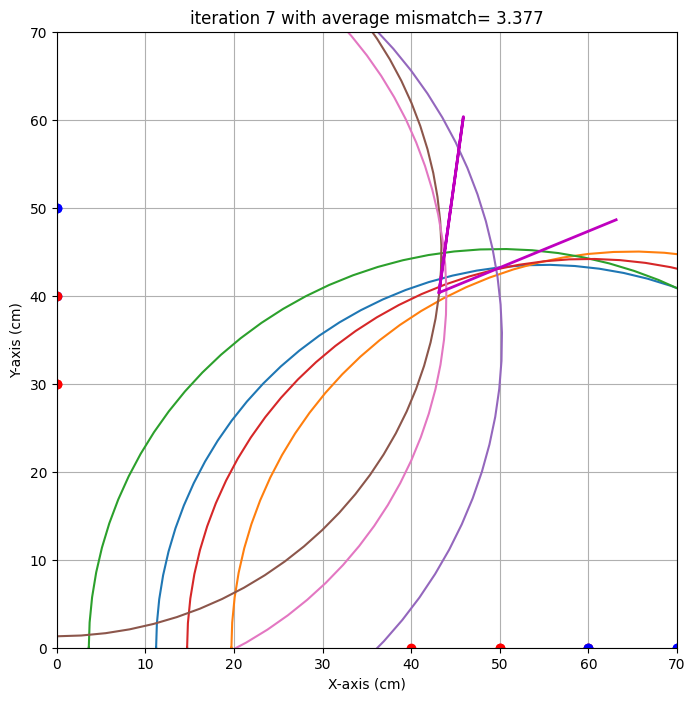

end iteration 7 with average mismatch= 3.377


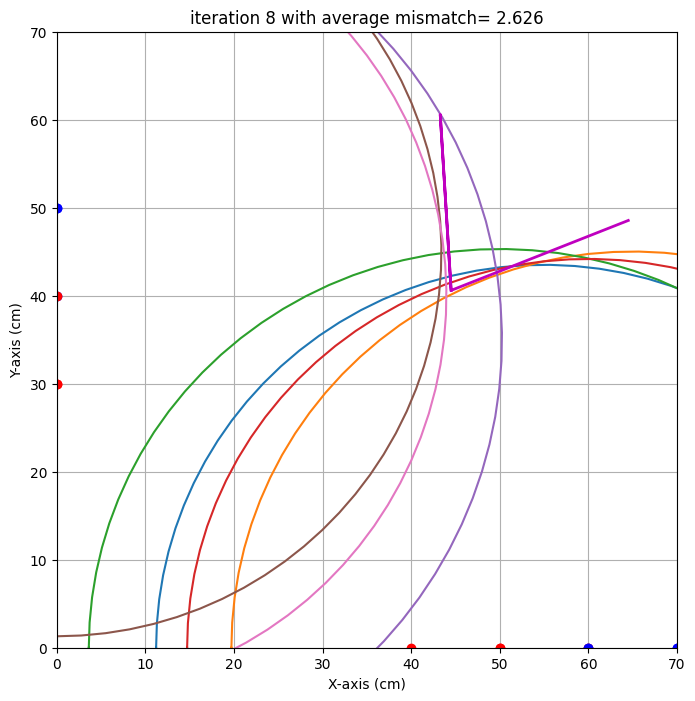

end iteration 8 with average mismatch= 2.626


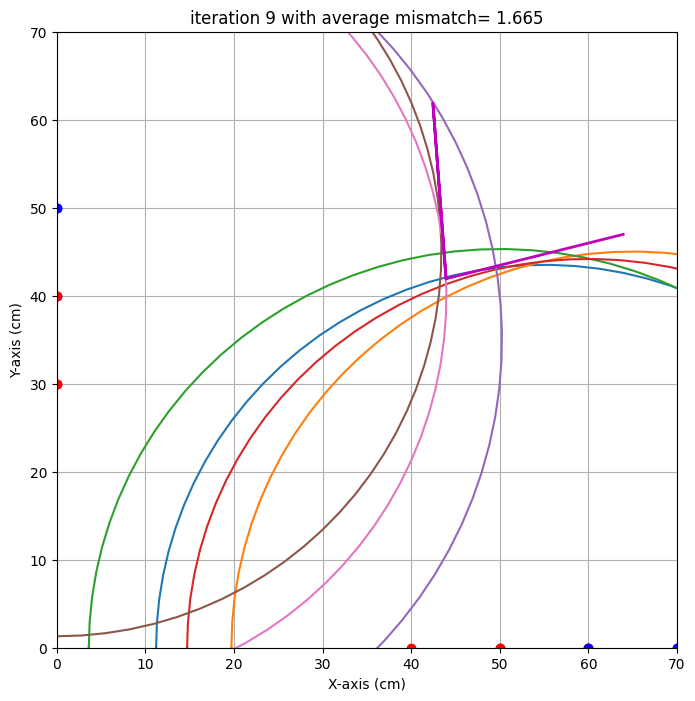

end iteration 9 with average mismatch= 1.665


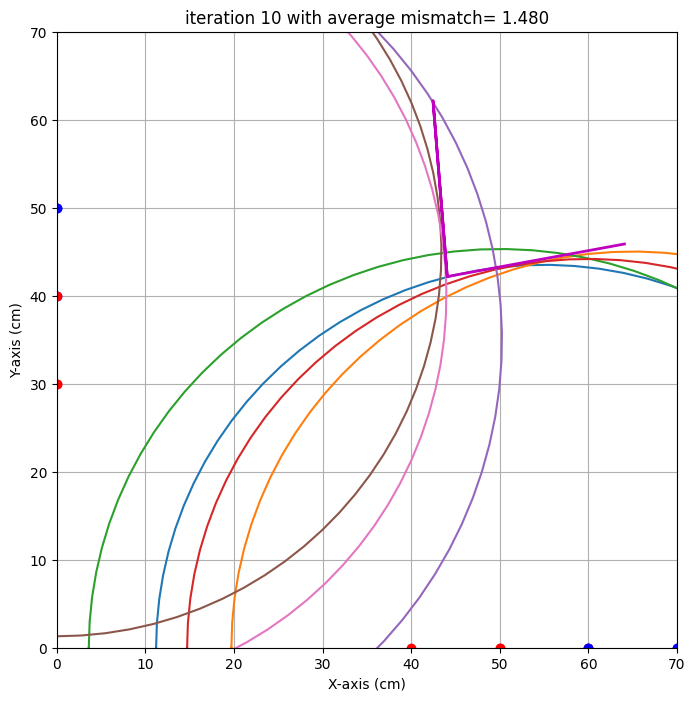

end iteration 10 with average mismatch= 1.480
end iteration 11 with average mismatch= 1.369
end iteration 12 with average mismatch= 1.313
end iteration 13 with average mismatch= 1.243
end iteration 14 with average mismatch= 1.190
end iteration 15 with average mismatch= 1.179
end iteration 16 with average mismatch= 1.175
end iteration 17 with average mismatch= 1.173
end iteration 18 with average mismatch= 1.173
end iteration 19 with average mismatch= 1.173
end iteration 20 with average mismatch= 1.173
end iteration 21 with average mismatch= 1.173
end iteration 22 with average mismatch= 1.173
end iteration 23 with average mismatch= 1.173
end iteration 24 with average mismatch= 1.173
end iteration 25 with average mismatch= 1.173
end iteration 26 with average mismatch= 1.173
end iteration 27 with average mismatch= 1.173
end iteration 28 with average mismatch= 1.173
end iteration 29 with average mismatch= 1.173
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

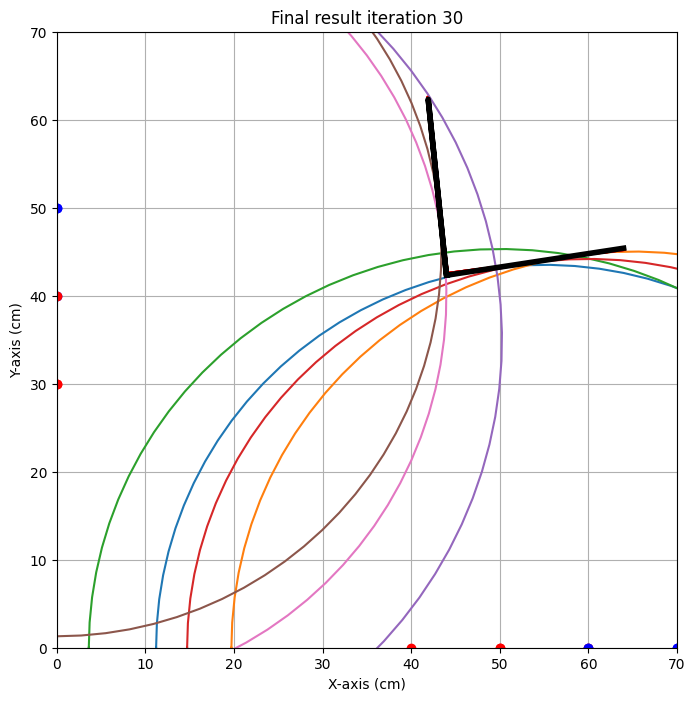

{'alpha': np.float64(8.736383049330312), 'alpha_eps': np.float64(1.524771873560404), 'beta': np.float64(-5.888614413453889), 'beta_eps': np.float64(0.7979552138527222), 'x0': np.float64(43.98070043980106), 'x0_eps': np.float64(0.1920499052616833), 'y0': np.float64(42.32535746209515), 'y0_eps': np.float64(0.316734090581285)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Pieter 
x0 target is : 46.0. Gevonden waarde: 43.0 cm met een standaardafwijking van 1.6 cm 
y0 target is : 44.0. Gevonden waarde: 43.1 cm met een standaardafwijking van 2.8 cm 
alpha target is : 6.0. Gevonden waarde: 5.5 graden met een standaardafwijking van 12.2 graad 
beta target is : -10.0. Gevonden waarde: 6.8 graden met een standaardafwijking van 5.0 graad 

Casper 
x0 target is : 46.0. Gevonden waarde: 44.7 cm met een standaardafwijking van 1.4 cm 
y0 target is : 44.0. Gevonden waarde: 44.8 cm met een standaardafwijking van 2.1 cm 
alpha target is : 6.0. Gevonden waarde: -1.2 graden met een standaardafwijking van 7.0 graad 
beta target is : -10.0. Gevonden waarde: 1.1 graden met een standaardafwijking van 7.8 graad 

Rune 
x0 target is : 46.0. Gevonden waarde: 44.0 cm met een standaardafwijking van 0.2 cm 
y0 target is : 44.0. Gevonden waarde: 42.3 cm met een standaardafwijking van 0.3 cm 
alpha target is : 6.0. Gevonden waarde: 8.7 graden met een standaardafwijking van 1.5 graa

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Alg1.jpeg)


## Opdracht 9: Iteratie 1+ meeting en test

Wegens een probleem met de Github merge zijn we onze data verloren. De geprintte figuren zijn nog wel over: 
Figuur: ![Alt](Figuur1.png)
Figuur: ![Alt](Figuur2.png)
Figuur: ![Alt](Figuur3.png)


In [10]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen},
           'locatie 2':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: '{' was never closed (786680266.py, line 4)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  55   0  113.0
1  50   0  65   0  118.0
2  40   0  50   0  114.0
3  40   0  60   0  115.5
4  45   0  55   0  114.0
5  35   0  55   0  114.0
6   0  42   0  67   58.0
7   0  42   0  72   59.5
8   0  42   0  77   60.5


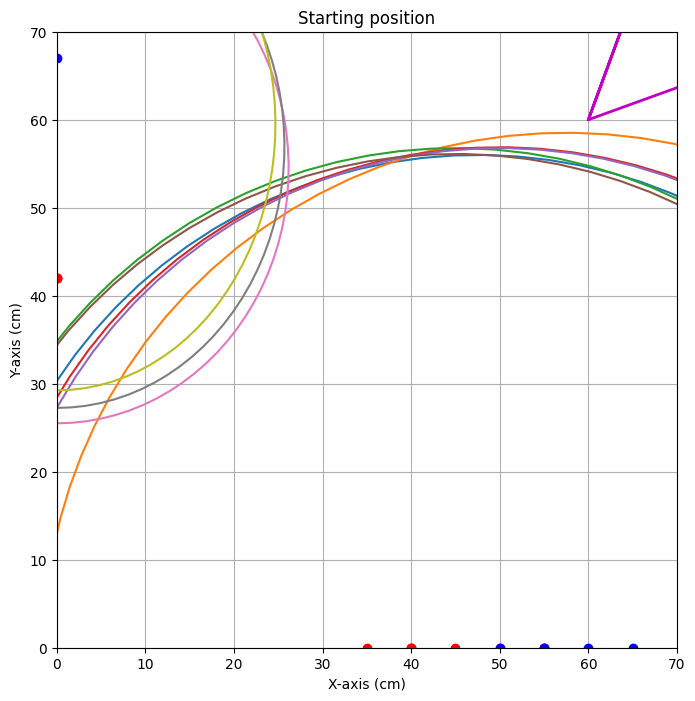


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=33.923


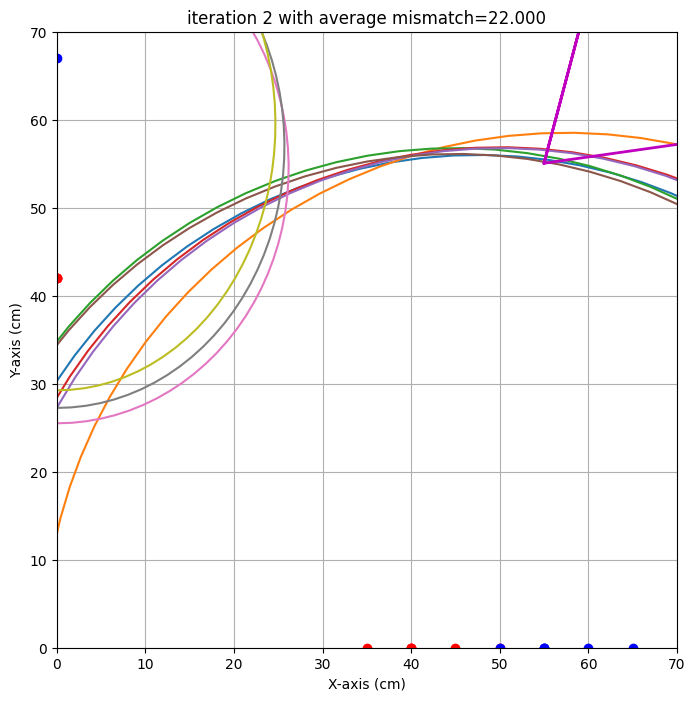

end iteration 2 with average mismatch=22.000


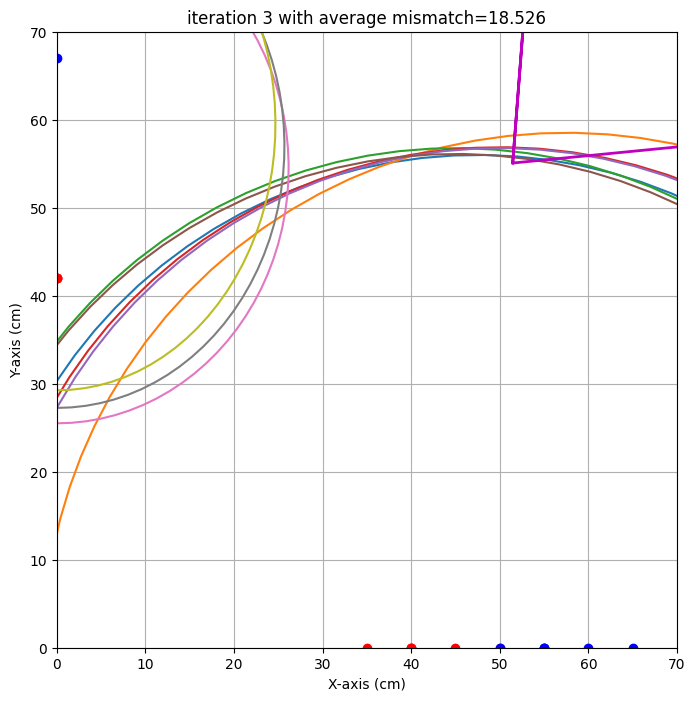

end iteration 3 with average mismatch=18.526


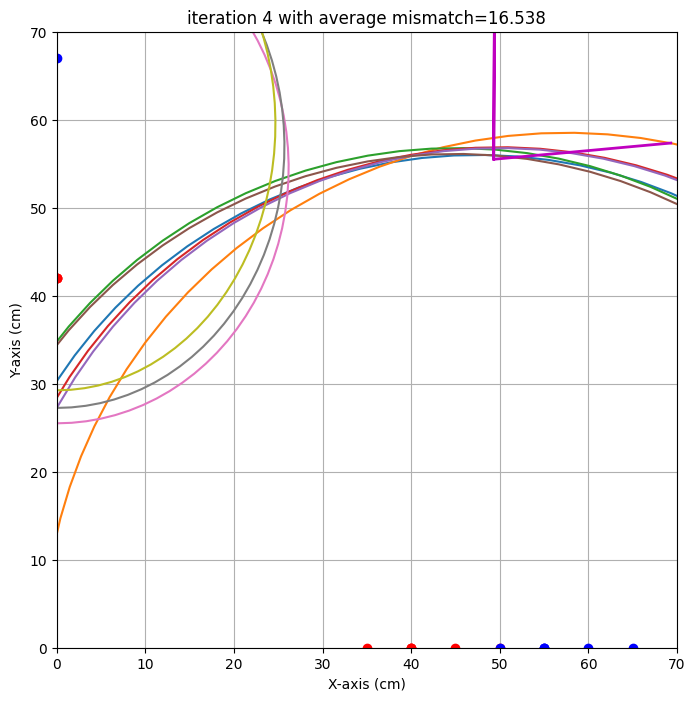

end iteration 4 with average mismatch=16.538
end iteration 5 with average mismatch=15.523


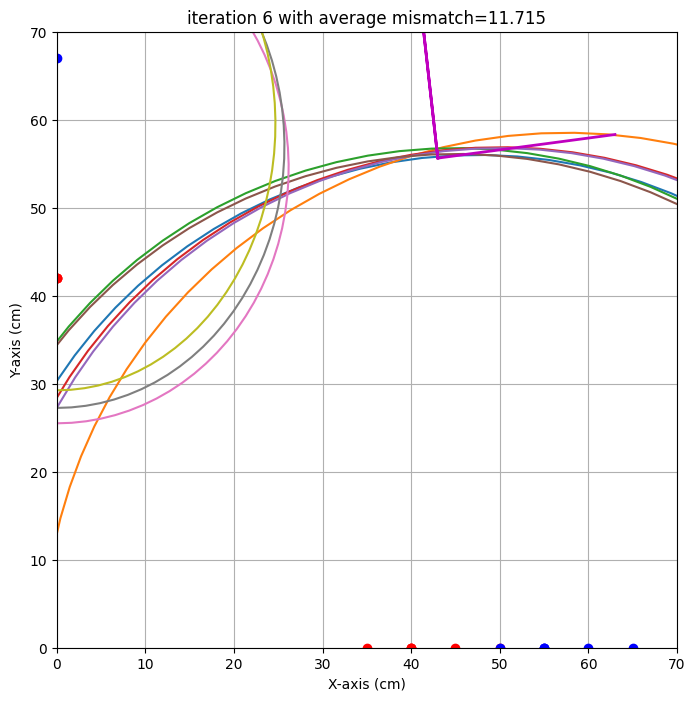

end iteration 6 with average mismatch=11.715


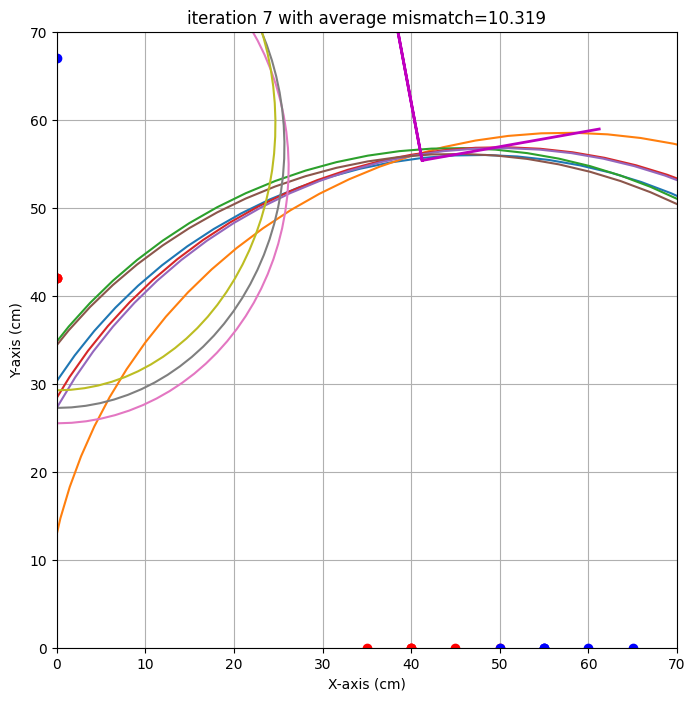

end iteration 7 with average mismatch=10.319


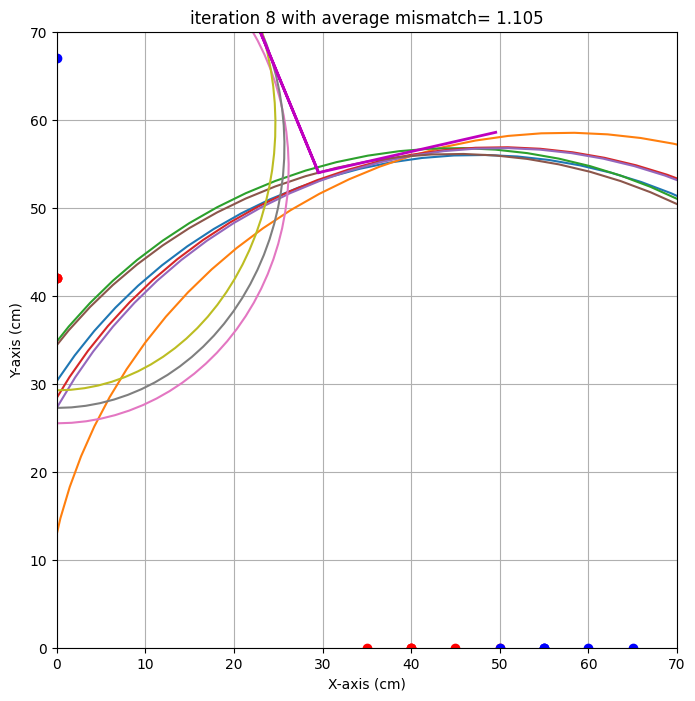

end iteration 8 with average mismatch= 1.105


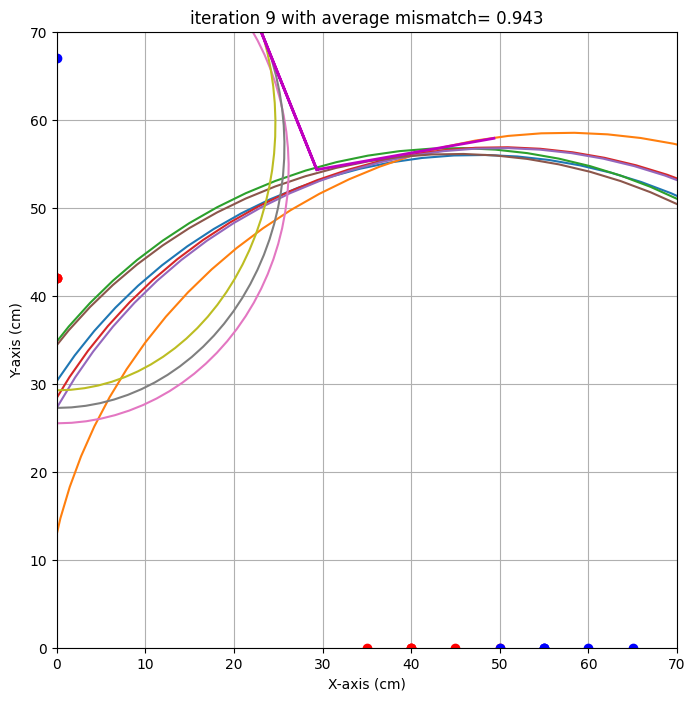

end iteration 9 with average mismatch= 0.943
end iteration 10 with average mismatch= 0.884


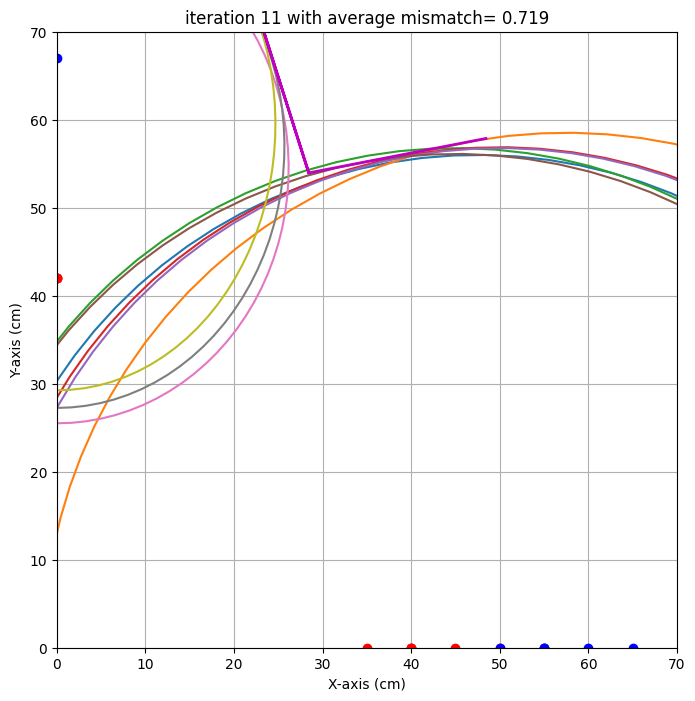

end iteration 11 with average mismatch= 0.719
end iteration 12 with average mismatch= 0.716
end iteration 13 with average mismatch= 0.695
end iteration 14 with average mismatch= 0.681
end iteration 15 with average mismatch= 0.680
end iteration 16 with average mismatch= 0.680
end iteration 17 with average mismatch= 0.679
end iteration 18 with average mismatch= 0.662
end iteration 19 with average mismatch= 0.655
end iteration 20 with average mismatch= 0.642
end iteration 21 with average mismatch= 0.642
end iteration 22 with average mismatch= 0.642
end iteration 23 with average mismatch= 0.642
end iteration 24 with average mismatch= 0.642
end iteration 25 with average mismatch= 0.642
end iteration 26 with average mismatch= 0.642
end iteration 27 with average mismatch= 0.642
end iteration 28 with average mismatch= 0.642
end iteration 29 with average mismatch= 0.642
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

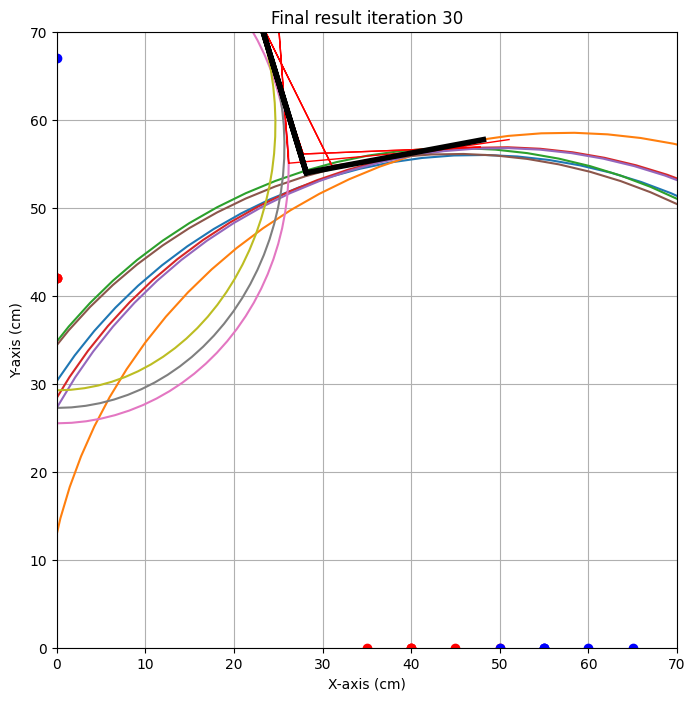

{'alpha': np.float64(10.659751480816544), 'alpha_eps': np.float64(8.40116429350656), 'beta': np.float64(-16.918302255784408), 'beta_eps': np.float64(12.749045330399705), 'x0': np.float64(28.152802794328416), 'x0_eps': np.float64(2.9001681667826418), 'y0': np.float64(53.97123624856659), 'y0_eps': np.float64(2.135888996489996)}
test locatie 
x0 target is : 27.6. Gevonden waarde: 28.2 cm met een standaardafwijking van 2.9 cm 
y0 target is : 53.5. Gevonden waarde: 54.0 cm met een standaardafwijking van 2.1 cm 
alpha target is : 12.0. Gevonden waarde: 10.7 graden met een standaardafwijking van 8.4 graad 
beta target is : -10.0. Gevonden waarde: -16.9 graden met een standaardafwijking van 12.7 graad 



In [11]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 27.6 ,
                    'y0':  53.5,
                    'alpha' : 12,
                    'beta' : -10
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,35,0,80.6],
    #[30,0,45,0,76.6],
    [40,0,55,0,113],
    [50,0,65,0,118.0],
    [40,0,50,0,114],  
    [40,0,60,0,115.5],
    [45,0,55,0,114.0],
    [35,0,55,0,114],
    #[0,62,0,82,86],
    #[0,57,0,82,0],
    #[0,52,0,82,67],
    #[0,47,0,82,66],
    [0,42,0,67,58],
    [0,42,0,72,59.5],
    [0,42,0,77,60.5],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Algoritme Pieter: ![Alt](AlgPieter.jpeg "Algoritme Pieter")

Algoritme Casper: ![Alt](AlgJasper.jpeg "1ste Test")

Algoritme Rune: ![Alt](AlgRune.jpeg "1ste Test")

Na de tests met onze algoritmes zijn we tot de conclusie gekomen dat het erg moeilijk is om objecten die ver weg staan (richting 60,60) te kunnen waarnemen. Daarom hebben we onze algoritmes samen gegooid en zijn er aparte takken gekomen voor de verschillende plaatsen waar de plaat kan staan. 

Iteratie 1: ![Alt](Alg1.jpeg "1ste iteratie")

Deze Iteratie zorgde ervoor dat we dachten dat breed meten (dus met de brandpunten verder uit elkaar) mogelijk een betere tactiek was om de uiteindelijke positie en hoek te kunnen meten

Iteratie 2: ![Alt](Alg2.jpeg "2de iteratie")

Uiteindelijk zijn we vrij aardig in de buurt gekomen bij de eindwaardes. Hoewel er nog wel wat te verbeteren valt, zeker in het opzicht van de hoek metingen.

Figuur: ![Alt](Senstest.jpeg "Testopstelling van sensor")
